# Telecom Churn EDA

This notebook performs exploratory data analysis on the validated M2 output at `data/processed/cleaned_data.csv`. The goal is to translate customer behavior patterns into churn decisions, KPI definitions, and business actions for the telecom team.

**Guardrails**
- Uses only the cleaned M2 dataset
- Does not alter M2 logic or source files
- Keeps analysis aligned to churn reduction, retention, and operational monitoring
- Treats `charge_amount` as a billing tier/category unless finance confirms it is true revenue
- Flags `status` and `complaints` as potentially leakage-prone for predictive modeling because they may sit close to the churn event


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', palette='deep')


## 1. Load And Validate Data

In [2]:
data_path = '../data/processed/cleaned_data.csv'
df = pd.read_csv(data_path)

print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nDtypes:')
print(df.dtypes)
print('\nChurn distribution:')
print(df['churn'].value_counts().sort_index())
print('\nChurn rate:', round(df['churn'].mean(), 4))

df.head()


Shape: (3150, 13)

Columns:
['id', 'subscription_length', 'charge_amount', 'seconds_of_use', 'frequency_of_use', 'frequency_of_sms', 'distinct_called_numbers', 'call_failures', 'tariff_plan', 'status', 'age_group', 'complaints', 'churn']

Dtypes:
id                          int64
subscription_length         int64
charge_amount               int64
seconds_of_use              int64
frequency_of_use            int64
frequency_of_sms            int64
distinct_called_numbers     int64
call_failures               int64
tariff_plan                object
status                     object
age_group                  object
complaints                 object
churn                       int64
dtype: object

Churn distribution:
churn
0    2655
1     495
Name: count, dtype: int64

Churn rate: 0.1571


,id,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,call_failures,tariff_plan,status,age_group,complaints,churn
0,1,35,0,1420,41,36,20,1,A,Active,30-40,N,0
1,2,28,0,920,32,20,12,7,A,Active,Under 30,N,0
2,3,40,0,88,6,8,6,0,A,Inactive,30-40,N,1
3,4,38,0,13963,170,9,47,9,A,Active,30-40,N,0
4,5,38,0,13773,169,0,44,7,A,Active,30-40,N,0


**Validation takeaway**

The cleaned dataset contains 3,150 customers across 13 fields, and `churn` is confirmed as the target column. The churn base rate is about **15.7%**, which means retention efforts should be calibrated to a minority-risk population rather than assuming churn is evenly spread across the base.


## 2. KPI Framework

| KPI Name | Formula | Business Meaning | Linked Objective |
|---|---|---|---|
| Churn Rate | `sum(churn) / customer_count` | Share of customers leaving the service | Reduce customer losses |
| Average Subscription Length | `mean(subscription_length)` | Average customer tenure in months | Improve loyalty and retention maturity |
| Average Charge Tier | `mean(charge_amount)` | Average billing tier/category in the customer base | Monitor value mix across retained vs churned customers |
| Usage Intensity | `seconds_of_use / subscription_length` | Monthly-normalized voice engagement | Detect disengagement before churn |
| Engagement Intensity | `frequency_of_use / subscription_length` | Monthly-normalized service interaction frequency | Track habit formation and stickiness |
| SMS Intensity | `frequency_of_sms / subscription_length` | Monthly-normalized SMS usage | Understand cross-channel engagement depth |
| Call Failure Rate | `call_failures / frequency_of_use` | Operational friction per observed usage event | Reduce network pain points tied to churn |
| Network Reach Ratio | `distinct_called_numbers / frequency_of_use` | Breadth of calling relationships relative to activity | Separate habitual users from narrow or sporadic users |
| Complaint Rate | `count(complaints == 'Y') / customer_count` | Share of customers raising issues | Prioritize service recovery programs |
| Inactive Status Rate | `count(status == 'Inactive') / customer_count` | Share of accounts already showing inactivity | Measure risk concentration in dormant base |


In [3]:
df_eda = df.copy()

df_eda['usage_intensity'] = df_eda['seconds_of_use'] / df_eda['subscription_length']
df_eda['engagement_intensity'] = df_eda['frequency_of_use'] / df_eda['subscription_length']
df_eda['sms_intensity'] = df_eda['frequency_of_sms'] / df_eda['subscription_length']
df_eda['call_failure_rate'] = np.where(
    df_eda['frequency_of_use'] > 0,
    df_eda['call_failures'] / df_eda['frequency_of_use'],
    0
)
df_eda['network_reach_ratio'] = np.where(
    df_eda['frequency_of_use'] > 0,
    df_eda['distinct_called_numbers'] / df_eda['frequency_of_use'],
    0
)

usage_cut = df_eda['usage_intensity'].median()
tenure_cut = df_eda['subscription_length'].median()
failure_cut = df_eda['call_failure_rate'].median()

df_eda['usage_segment'] = np.where(df_eda['usage_intensity'] >= usage_cut, 'High usage', 'Low usage')
df_eda['charge_segment'] = np.where(df_eda['charge_amount'] > 0, 'Positive charge tier', 'Zero charge tier')
df_eda['tenure_segment'] = np.where(df_eda['subscription_length'] >= tenure_cut, 'Long tenure', 'Short tenure')
df_eda['failure_segment'] = np.where(df_eda['call_failure_rate'] >= failure_cut, 'High failure', 'Low failure')


## 3. Univariate Analysis

In [4]:
numeric_features = [
    'subscription_length', 'charge_amount', 'seconds_of_use', 'frequency_of_use',
    'frequency_of_sms', 'distinct_called_numbers', 'call_failures',
    'usage_intensity', 'engagement_intensity', 'sms_intensity', 'call_failure_rate'
]

summary_rows = []
for col in numeric_features:
    q1 = df_eda[col].quantile(0.25)
    q3 = df_eda[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    summary_rows.append({
        'feature': col,
        'mean': df_eda[col].mean(),
        'median': df_eda[col].median(),
        'skewness': df_eda[col].skew(),
        'outlier_count_iqr': ((df_eda[col] < lower) | (df_eda[col] > upper)).sum()
    })

summary_df = pd.DataFrame(summary_rows).sort_values('skewness', ascending=False)
summary_df


,feature,mean,median,skewness,outlier_count_iqr
9,sms_intensity,2.639,0.644,5.147,252
10,call_failure_rate,0.138,0.096,4.532,181
1,charge_amount,0.943,0.000,2.585,370
8,engagement_intensity,2.359,1.716,2.480,249
7,usage_intensity,152.664,97.041,2.094,210
4,frequency_of_sms,73.175,21.000,1.974,368
2,seconds_of_use,"4,472.460","2,990.000",1.322,200
3,frequency_of_use,69.461,54.000,1.144,129
6,call_failures,7.628,6.000,1.090,47
5,distinct_called_numbers,23.510,21.000,1.029,77


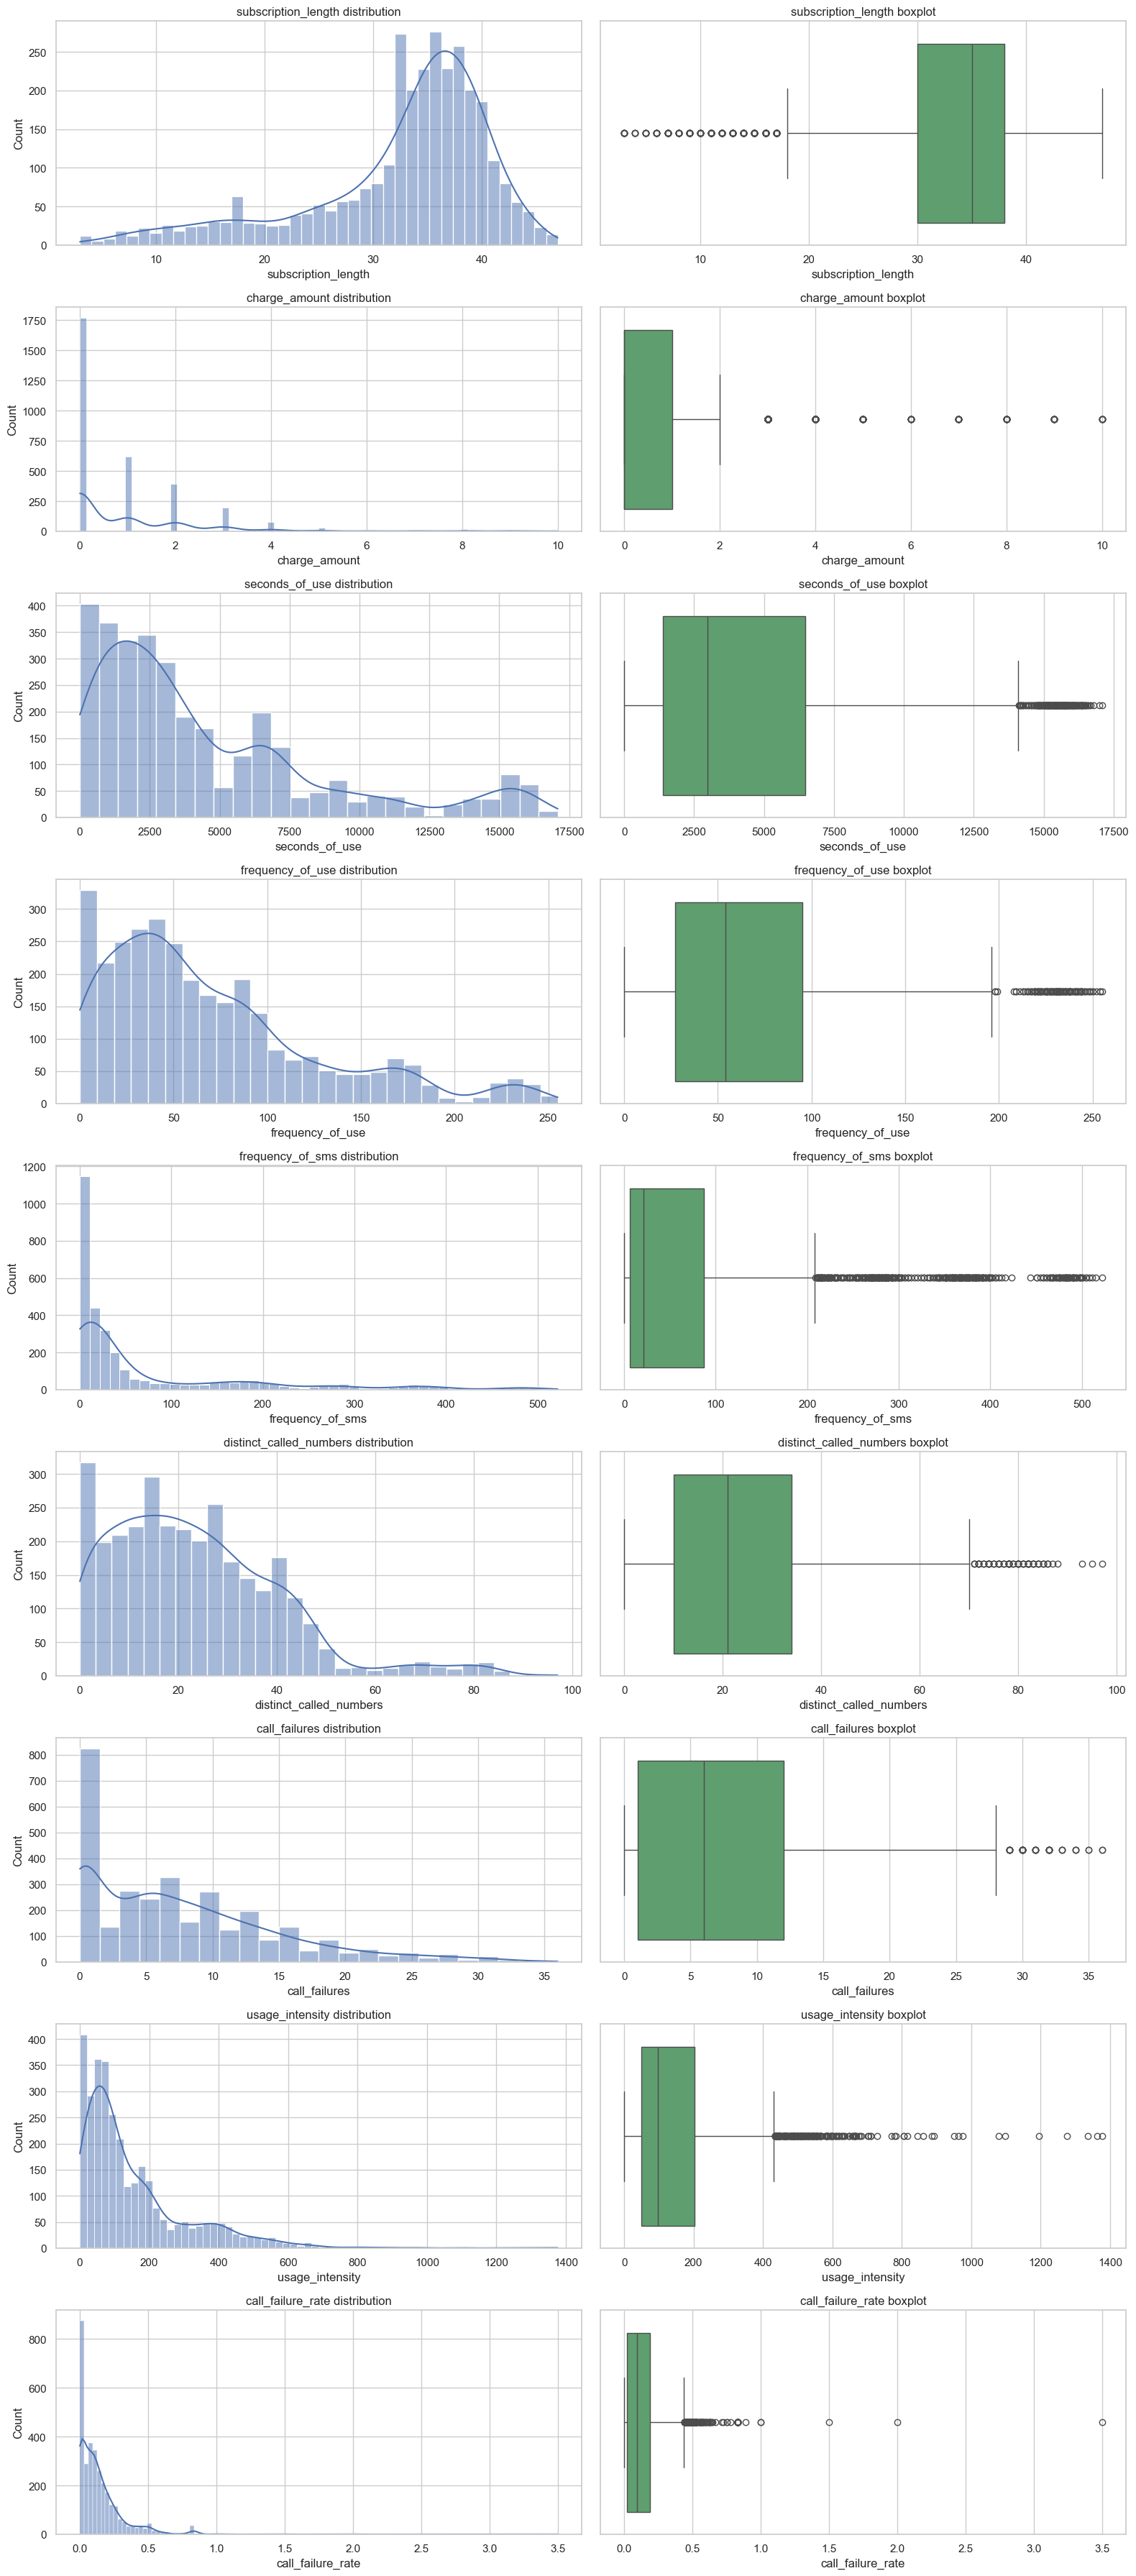

In [5]:
plot_features = [
    'subscription_length', 'charge_amount', 'seconds_of_use', 'frequency_of_use',
    'frequency_of_sms', 'distinct_called_numbers', 'call_failures', 'usage_intensity', 'call_failure_rate'
]

fig, axes = plt.subplots(len(plot_features), 2, figsize=(16, 4 * len(plot_features)))
for i, feature in enumerate(plot_features):
    sns.histplot(df_eda[feature], kde=True, ax=axes[i, 0], color='#4C72B0')
    axes[i, 0].set_title(f'{feature} distribution')

    sns.boxplot(x=df_eda[feature], ax=axes[i, 1], color='#55A868')
    axes[i, 1].set_title(f'{feature} boxplot')

plt.tight_layout()
plt.show()


**Distribution insights**

1. **Subscription length is left-skewed**, with many customers clustered in the 30 to 38 month range. That suggests the base is fairly mature, so churn prevention should prioritize detecting behavior change inside an established relationship rather than assuming churn is mostly a new-customer problem.
2. **Charge amount is heavily concentrated at zero or low values**, which reinforces that it behaves more like a billing tier/category than a smooth revenue metric. This makes it useful for segmentation, but not for revenue forecasting without business confirmation.
3. **Seconds of use, frequency of use, and SMS activity are all right-skewed**, meaning a relatively small group of highly engaged users drives a disproportionate share of network activity. Those customers are strategic to retain because losing them can hurt both volume and value mix.
4. **Call failures also show a long upper tail**, indicating a smaller subset experiences substantially more friction than the typical customer. That tail deserves operational monitoring because service pain often turns into preventable churn.
5. **Usage intensity and call failure rate both surface meaningful outliers**, which are not automatically bad records in telecom data. Instead, they mark customer experiences that are materially different from the norm and should be reviewed as potential risk pockets or high-value cohorts.


## 4. Bivariate Analysis With Churn

In [6]:
churn_means = df_eda.groupby('churn')[numeric_features].mean().T
churn_means.columns = ['Retained (0)', 'Churned (1)']
churn_means['Difference (Churned - Retained)'] = churn_means['Churned (1)'] - churn_means['Retained (0)']
churn_means.sort_values('Difference (Churned - Retained)')


,Retained (0),Churned (1),Difference (Churned - Retained)
seconds_of_use,"5,014.224","1,566.632","-3,447.592"
usage_intensity,169.536,62.170,-107.365
frequency_of_sms,83.872,15.802,-68.070
frequency_of_use,76.979,29.133,-47.846
distinct_called_numbers,25.583,12.392,-13.191
sms_intensity,3.036,0.506,-2.530
engagement_intensity,2.605,1.038,-1.567
charge_amount,1.076,0.230,-0.845
subscription_length,32.663,31.895,-0.768
call_failures,7.656,7.477,-0.179


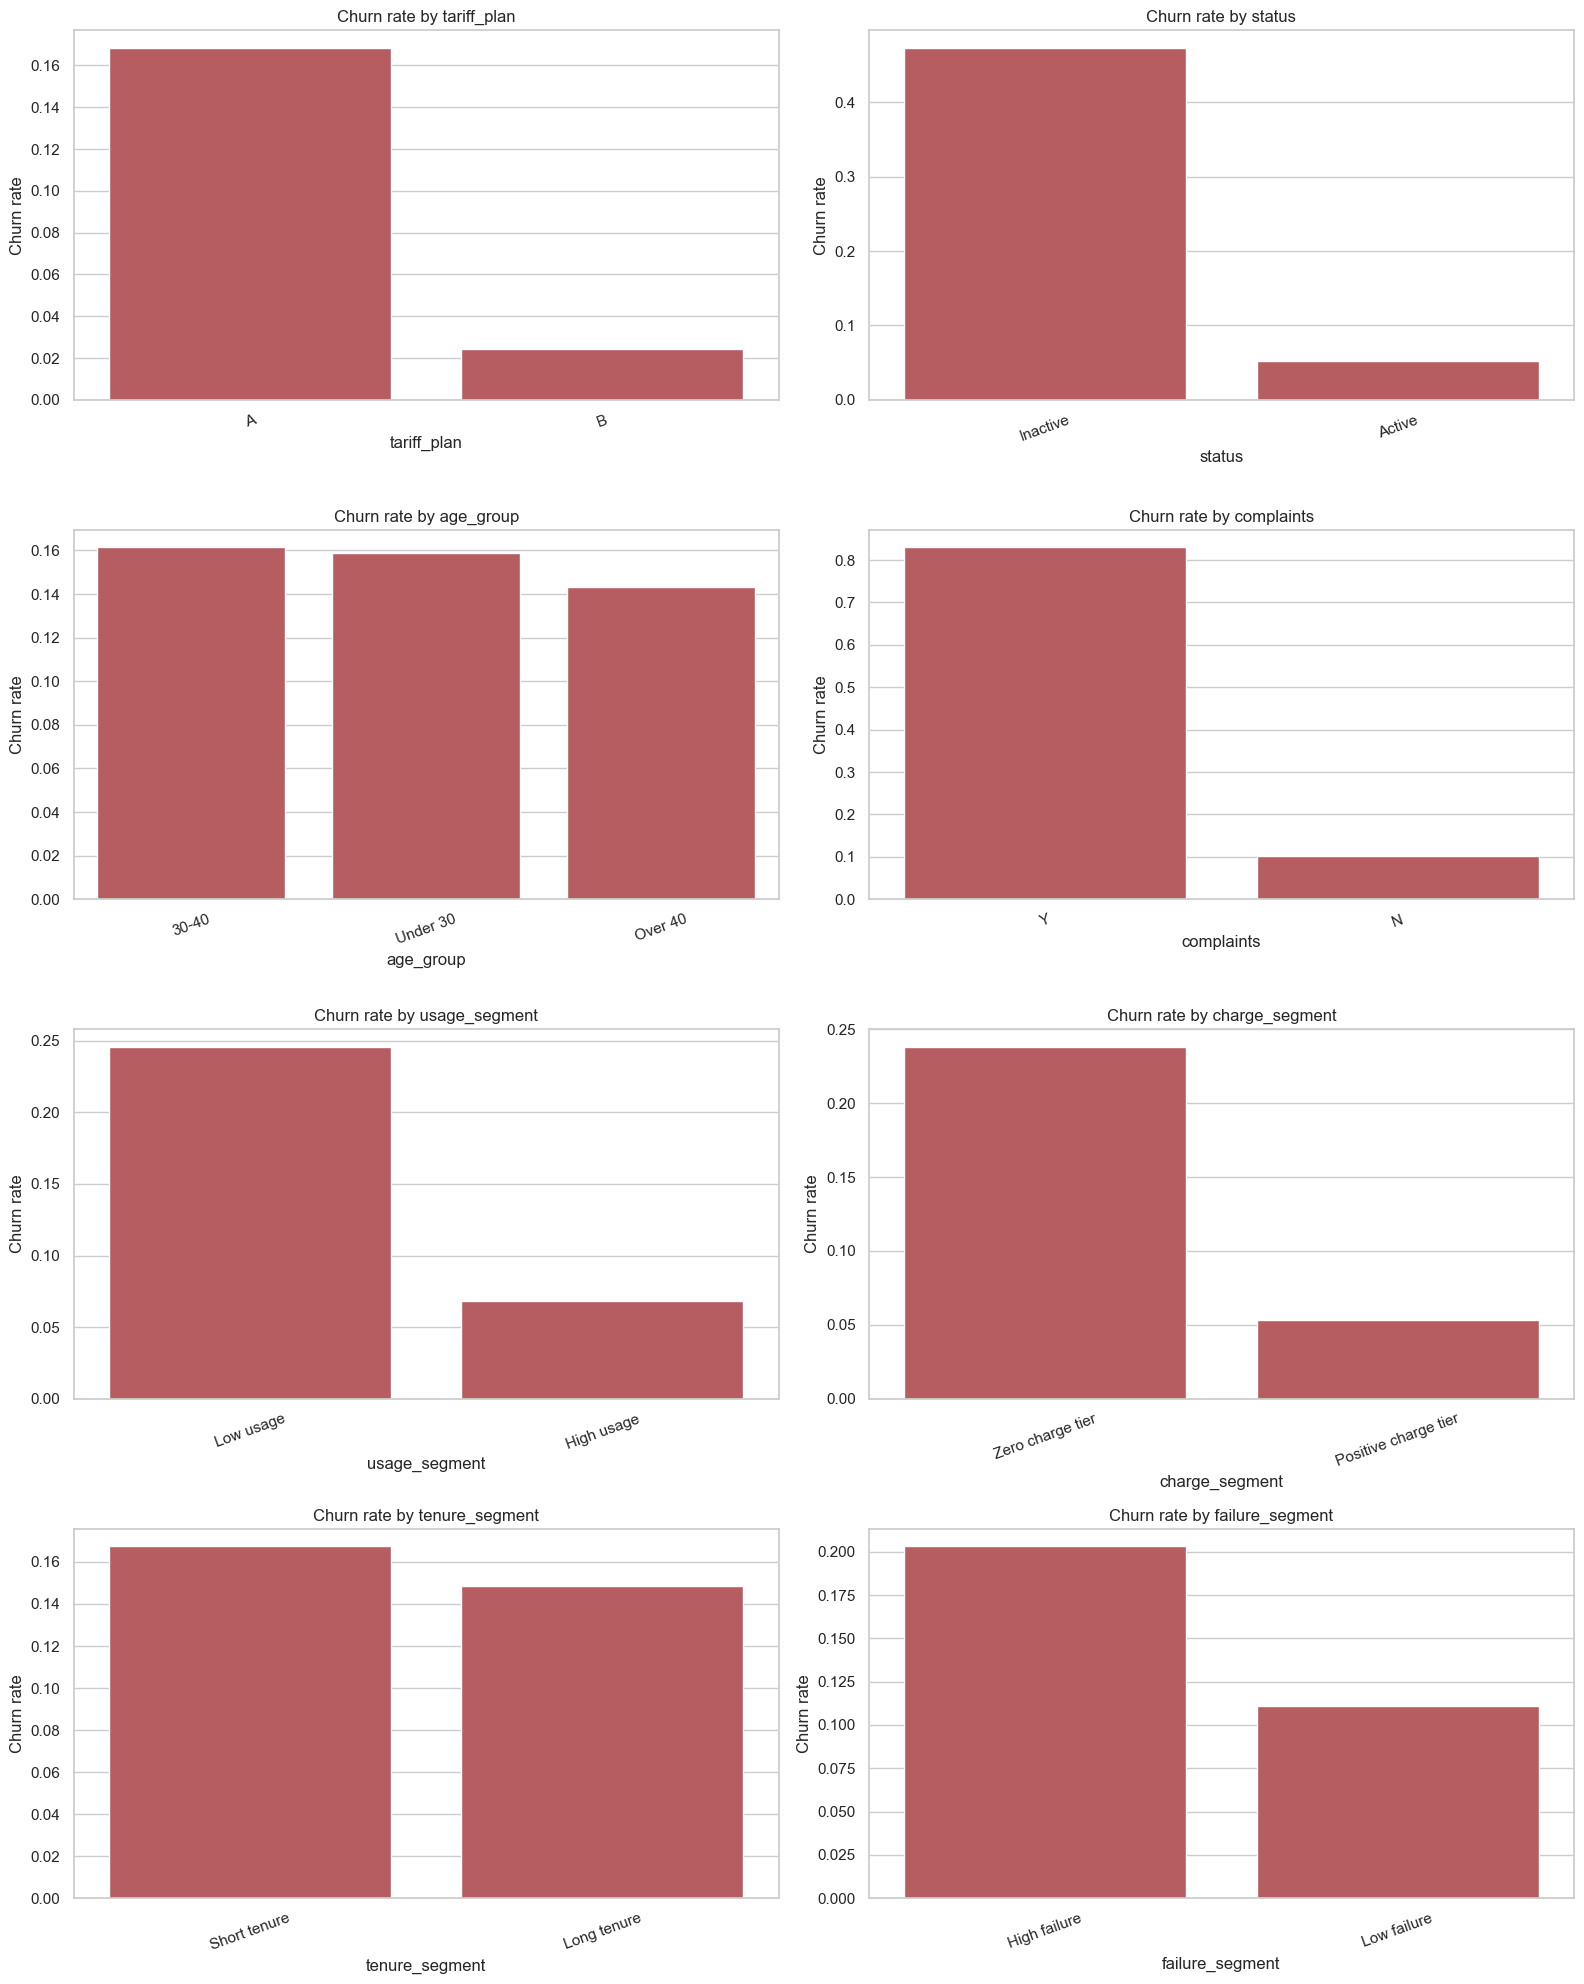

In [7]:
categorical_features = ['tariff_plan', 'status', 'age_group', 'complaints', 'usage_segment', 'charge_segment', 'tenure_segment', 'failure_segment']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()
for ax, feature in zip(axes, categorical_features):
    rate_df = (df_eda.groupby(feature)['churn']
               .mean()
               .sort_values(ascending=False)
               .reset_index())
    sns.barplot(data=rate_df, x=feature, y='churn', ax=ax, color='#C44E52')
    ax.set_title(f'Churn rate by {feature}')
    ax.set_ylabel('Churn rate')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


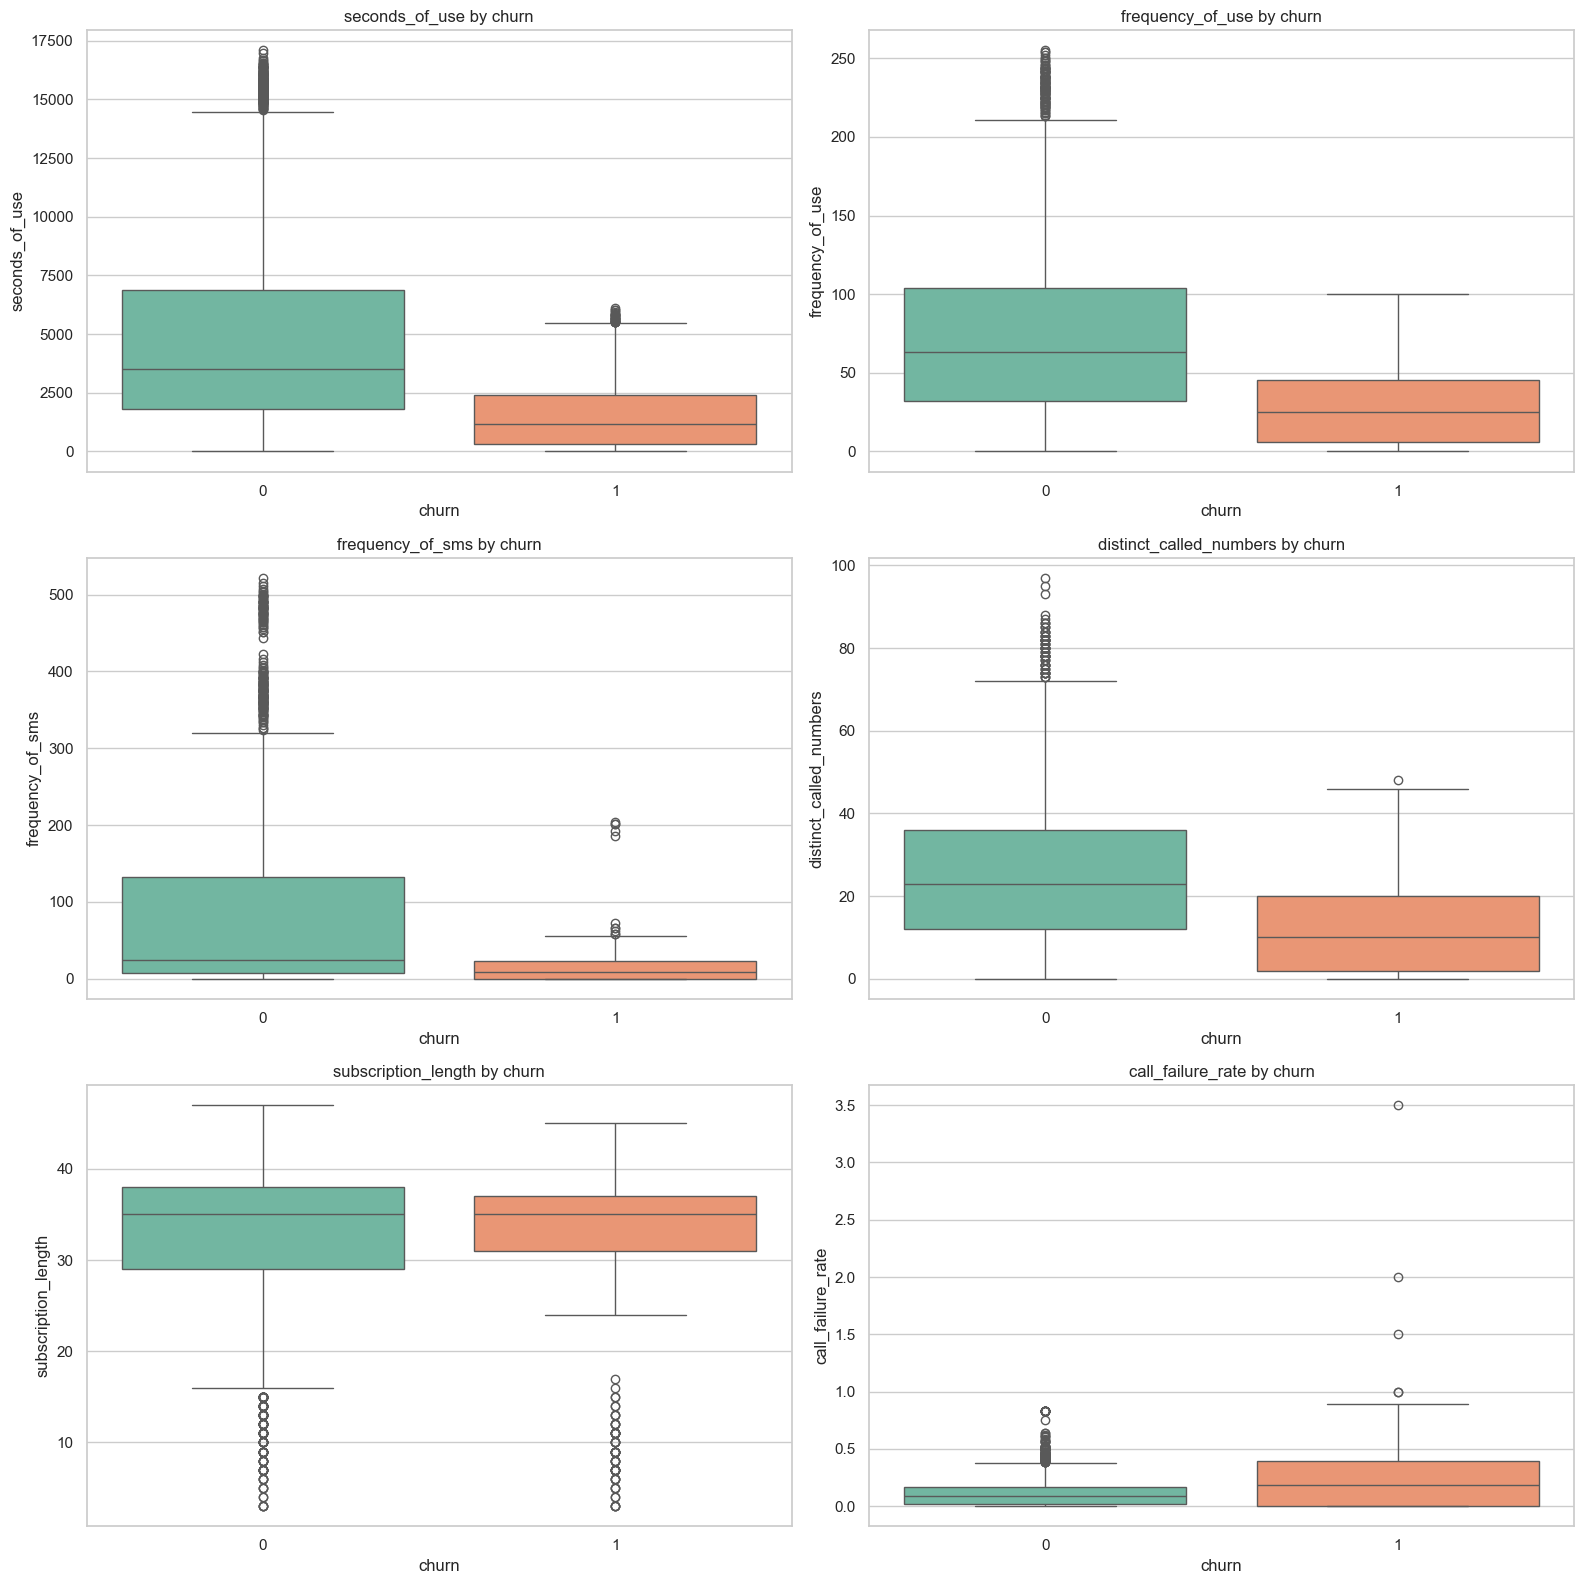

In [8]:
boxplot_features = ['seconds_of_use', 'frequency_of_use', 'frequency_of_sms', 'distinct_called_numbers', 'subscription_length', 'call_failure_rate']

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()
for ax, feature in zip(axes, boxplot_features):
    sns.boxplot(data=df_eda, x='churn', y=feature, ax=ax, palette='Set2')
    ax.set_title(f'{feature} by churn')

plt.tight_layout()
plt.show()


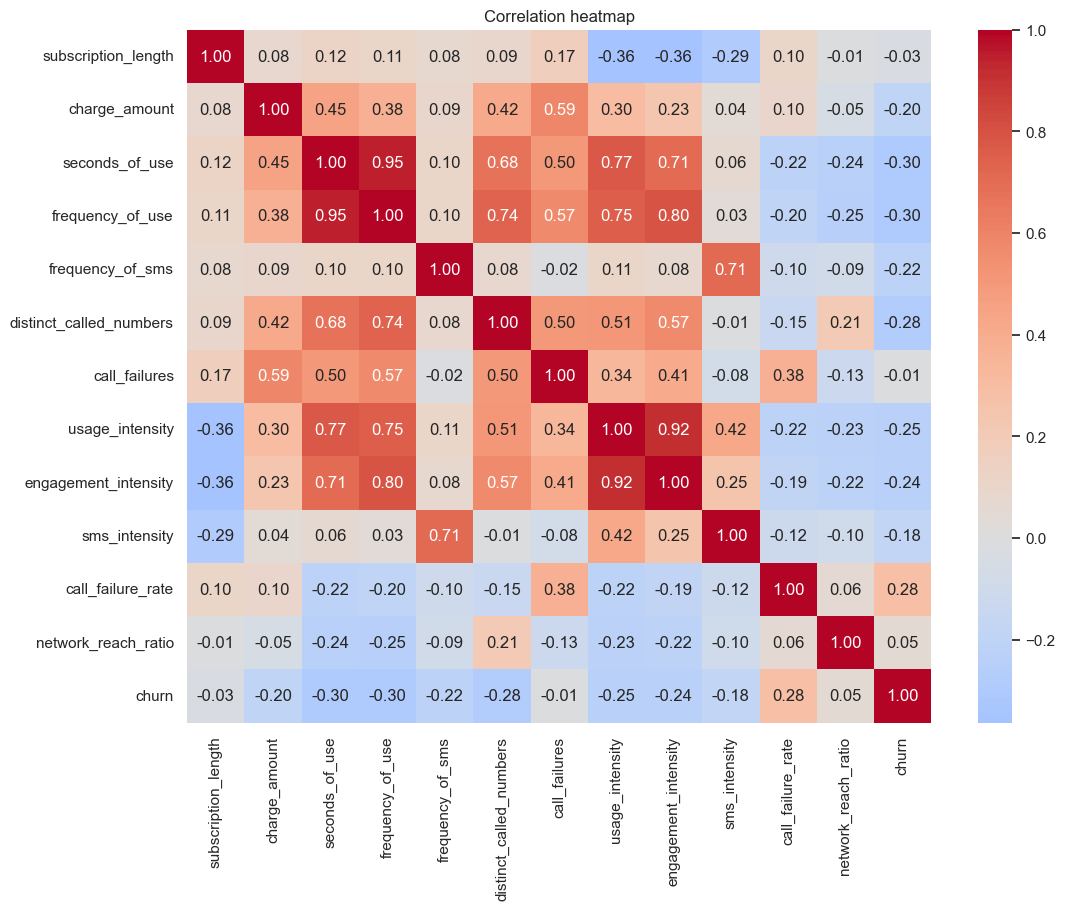

In [9]:
corr_cols = [
    'subscription_length', 'charge_amount', 'seconds_of_use', 'frequency_of_use',
    'frequency_of_sms', 'distinct_called_numbers', 'call_failures', 'usage_intensity',
    'engagement_intensity', 'sms_intensity', 'call_failure_rate', 'network_reach_ratio', 'churn'
]

plt.figure(figsize=(12, 9))
sns.heatmap(df_eda[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.show()


**Churn-driver insights**

1. **Churned customers are much less engaged than retained customers.** Their average voice usage, usage frequency, SMS activity, and number of distinct contacts are all materially lower. This points to disengagement as a central churn signal, not just billing or demographics.
2. **Call failures in absolute terms look similar across churn groups, but failure rate tells a more important story.** Customers who churn are not necessarily seeing more total failures because they use the service less; they are experiencing more friction relative to how often they engage. That makes normalized operational KPIs more decision-useful than raw failure counts.
3. **Inactive status and complaints are extreme churn indicators.** These fields are valuable for operational triage and dashboarding, but they should be treated carefully in predictive modeling because they may reflect events that occur very close to the churn outcome.
4. **Tariff plan B customers churn far less than plan A customers in this dataset.** That may indicate stronger fit, better economics, or better experience for those subscribers, which makes plan design worth reviewing from a retention lens.
5. **Age group differences exist but are modest compared with behavior and service-quality signals.** That means churn programs will likely get more lift from behavior-based targeting than from demographic targeting alone.


## 5. Segment Analysis

In [10]:
segment_rate_tables = {}
for feature in ['usage_segment', 'charge_segment', 'tenure_segment', 'failure_segment']:
    segment_rate_tables[feature] = (df_eda.groupby(feature)['churn']
                                    .agg(['count', 'mean'])
                                    .rename(columns={'count': 'customers', 'mean': 'churn_rate'})
                                    .sort_values('churn_rate', ascending=False))

segment_rate_tables['usage_segment']


,customers,churn_rate
usage_segment,,
Low usage,1575,0.246
High usage,1575,0.069


In [11]:
for feature, table in segment_rate_tables.items():
    print(f'\n{feature}')
    display(table)

combo_risk = (df_eda.groupby(['tenure_segment', 'failure_segment', 'usage_segment', 'complaints'])['churn']
              .agg(['count', 'mean'])
              .rename(columns={'count': 'customers', 'mean': 'churn_rate'})
              .query('customers >= 40')
              .sort_values('churn_rate', ascending=False))
combo_risk.head(12)



usage_segment

charge_segment

tenure_segment

failure_segment


,customers,churn_rate
usage_segment,,
Low usage,1575,0.246
High usage,1575,0.069


,customers,churn_rate
charge_segment,,
Zero charge tier,1768,0.238
Positive charge tier,1382,0.054


,customers,churn_rate
tenure_segment,,
Short tenure,1445,0.167
Long tenure,1705,0.148


,customers,churn_rate
failure_segment,,
High failure,1575,0.203
Low failure,1575,0.111


customers  churn_rate
tenure_segment failure_segment usage_segment complaints                       
Short tenure   High failure    Low usage     Y                  41       0.976
Long tenure    High failure    Low usage     Y                  91       0.824
                                             N                 477       0.201
               Low failure     Low usage     N                 303       0.175
Short tenure   Low failure     Low usage     N                 338       0.151
               High failure    Low usage     N                 292       0.137
                               High usage    N                 250       0.092
               Low failure     High usage    N                 450       0.044
Long tenure    High failure    High usage    N                 369       0.027
               Low failure     High usage    N                 430       0.005

**Segment insights**

- **Low-usage customers churn at a far higher rate than high-usage customers**, which makes declining engagement one of the clearest retention triggers in the base.
- **Zero-charge-tier customers churn much more than positive-charge-tier customers**. Even if `charge_amount` is categorical, it still flags a lower-value or less-committed cohort that deserves special retention packaging.
- **Short-tenure customers churn slightly more than long-tenure customers**, but tenure alone is not the whole story. The bigger risk appears when short tenure overlaps with low usage or poor service experience.
- **High-failure-rate customers churn at nearly double the rate of low-failure-rate customers**, reinforcing that quality of experience matters as much as activity volume.
- **The highest-risk segment combines short tenure, high failure rate, low usage, and complaints**, which is exactly the kind of cohort a telecom retention team can operationalize for immediate save actions.


## 6. Correlation And Feature Relationships

In [12]:
corr_matrix = df_eda[corr_cols].corr()
churn_corr = corr_matrix['churn'].drop('churn').sort_values()

strong_pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                .stack()
                .reset_index())
strong_pairs.columns = ['feature_1', 'feature_2', 'correlation']
strong_pairs['abs_correlation'] = strong_pairs['correlation'].abs()
strong_pairs.sort_values('abs_correlation', ascending=False).head(15)


,feature_1,feature_2,correlation,abs_correlation
23,seconds_of_use,frequency_of_use,0.946,0.946
63,usage_intensity,engagement_intensity,0.915,0.915
37,frequency_of_use,engagement_intensity,0.795,0.795
27,seconds_of_use,usage_intensity,0.775,0.775
36,frequency_of_use,usage_intensity,0.755,0.755
34,frequency_of_use,distinct_called_numbers,0.736,0.736
46,frequency_of_sms,sms_intensity,0.709,0.709
28,seconds_of_use,engagement_intensity,0.705,0.705
25,seconds_of_use,distinct_called_numbers,0.677,0.677
16,charge_amount,call_failures,0.589,0.589


In [13]:
churn_corr.to_frame('correlation_with_churn')


,correlation_with_churn
frequency_of_use,-0.303
seconds_of_use,-0.299
distinct_called_numbers,-0.279
usage_intensity,-0.246
engagement_intensity,-0.243
frequency_of_sms,-0.221
charge_amount,-0.202
sms_intensity,-0.182
subscription_length,-0.033
call_failures,-0.009


**Relationship insights**

- `seconds_of_use` and `frequency_of_use` are extremely correlated, so they describe nearly the same engagement story. For downstream statistical work, we should watch for redundancy and avoid over-weighting both in the same simple model without checking multicollinearity.
- Derived intensity metrics are strongly tied to the raw usage metrics, which is expected. Their advantage is interpretability: they normalize behavior by tenure and make it easier to compare customers at different lifecycle stages.
- `call_failure_rate` has a clearer positive relationship with churn than raw `call_failures`, which confirms that normalized service friction is the more actionable risk signal.
- The strongest negative relationships with churn are the usage variables. In business terms, churn looks much more like disengagement plus friction than like a pure demographic effect.


## 7. Insights Summary

1. **Low engagement is the clearest churn signature** -> Churned customers use fewer seconds, place fewer interactions, send fewer SMS messages, and contact fewer unique numbers -> Trigger early-warning retention programs when activity drops below the median or falls sharply month over month.
2. **Usage intensity separates risky customers from stable ones** -> The lowest usage-intensity quartile has materially higher churn than the highest quartile -> Prioritize outbound campaigns for customers showing weak monthly-normalized usage.
3. **Service friction matters most when normalized** -> Raw call failures are not very different across churn groups, but call failure rate rises sharply in higher-risk segments -> Use failure rate as the operational KPI for network-led churn prevention.
4. **Complaints are a major churn alarm** -> Customers with complaints churn at dramatically higher rates than those without complaints -> Build a fast-track complaint recovery workflow with proactive callbacks and save offers.
5. **Inactive accounts are already deep in the danger zone** -> Inactive customers churn at much higher rates than active customers -> Treat inactivity as a retention escalation state, not just a passive dashboard label.
6. **Tariff plan structure may influence retention** -> Plan B customers churn far less than plan A customers in this dataset -> Audit plan A value proposition, pricing fairness, and service experience to identify retention gaps.
7. **Zero-charge-tier customers are much more fragile** -> Customers in the zero charge tier churn far more than those in positive tiers -> Test affordable bundle upgrades or stickiness incentives for the low-charge cohort.
8. **Tenure helps, but behavior matters more** -> Long-tenure customers do somewhat better, yet churn still spikes when tenure weakness combines with low usage or high failures -> Use tenure as a supporting feature, not the primary retention rule.
9. **The riskiest customers show multiple warning signs at once** -> Short tenure, low usage, high failure rate, and complaints together create an especially severe churn pocket -> Operationalize a multi-trigger risk queue for customer care and retention teams.
10. **A small group of heavy users drives outsized activity** -> Right-skewed usage distributions show that a minority of customers accounts for a large share of network engagement -> Protect high-value active users with premium care and experience monitoring.
11. **Demographics are secondary to behavior** -> Age-group differences are modest relative to usage and service-quality gaps -> Focus churn strategy on what customers do and experience, not who they are.
12. **Leakage-aware modeling design is essential** -> `status` and `complaints` are highly predictive, but they may occur close to churn -> Keep them for Tableau and operational KPIs, while testing leakage-safe model variants for M4 statistics work.
